# Dataset Token Length Comparison
Compare token-length distributions of:
- `OpenLLM-Ro/fineweb2-ro-llm` (Romanian web text)
- `danp27/fineweb-edu-500k-sample` (English educational web text)

Tokenizer: `meta-llama/Llama-3.2-1B`

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path("../../.env")
load_dotenv(env_path)
HF_TOKEN = os.environ.get("HF_TOKEN")

In [2]:
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt

N_SAMPLES = 1000
MODEL_NAME = "meta-llama/Llama-3.2-1B"

DATASETS = {
    "fineweb2-ro (RO)": {
        "path": "OpenLLM-Ro/fineweb2-ro-llm",
        "text_col": "text",
    },
    "fineweb-edu (EN)": {
        "path": "danp27/fineweb-edu-500k-sample",
        "text_col": "text",
    },
}

/home/dan-parii/.pyenv/versions/finetuning-ro-llms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
print(f"Vocab size: {tokenizer.vocab_size:,}")

Loading tokenizer: meta-llama/Llama-3.2-1B
Vocab size: 128,000


In [4]:
def load_samples(ds_path, text_col, n, token):
    """Stream n samples from a HuggingFace dataset."""
    ds = load_dataset(ds_path, split="train", streaming=True, token=token)
    texts = [row[text_col] for _, row in zip(range(n), ds)]
    print(f"  Loaded {len(texts)} samples from {ds_path}")
    return texts


def tokenize_texts(texts, tokenizer):
    """Tokenize a list of texts and return token counts per sample."""
    token_lengths = []
    for text in texts:
        ids = tokenizer(text, truncation=False, add_special_tokens=False)["input_ids"]
        token_lengths.append(len(ids))
    return np.array(token_lengths)


results = {}
for ds_label, cfg in DATASETS.items():
    print(f"\n--- {ds_label} ---")
    texts = load_samples(cfg["path"], cfg["text_col"], N_SAMPLES, HF_TOKEN)
    lengths = tokenize_texts(texts, tokenizer)
    results[ds_label] = lengths
    print(f"  mean={lengths.mean():.0f}  median={np.median(lengths):.0f}  "
          f"p95={np.percentile(lengths, 95):.0f}  max={lengths.max()}")


--- fineweb2-ro (RO) ---
  Loaded 1000 samples from OpenLLM-Ro/fineweb2-ro-llm
  mean=932  median=530  p95=2705  max=37693

--- fineweb-edu (EN) ---
  Loaded 1000 samples from danp27/fineweb-edu-500k-sample
  mean=1073  median=574  p95=3334  max=78547


In [5]:
# ── Summary statistics table ──────────────────────────────────────────────────
print(f"{'Metric':<12}", end="")
for label in results:
    print(f"{label:>22}", end="")
print()
print("-" * (12 + 22 * len(results)))

stats = {
    "mean":   lambda x: np.mean(x),
    "median": lambda x: np.median(x),
    "p25":    lambda x: np.percentile(x, 25),
    "p75":    lambda x: np.percentile(x, 75),
    "p95":    lambda x: np.percentile(x, 95),
    "p99":    lambda x: np.percentile(x, 99),
    "max":    lambda x: np.max(x),
}

for stat_name, fn in stats.items():
    print(f"{stat_name:<12}", end="")
    for lengths in results.values():
        print(f"{fn(lengths):>22.0f}", end="")
    print()

Metric            fineweb2-ro (RO)      fineweb-edu (EN)
--------------------------------------------------------
mean                           932                  1073
median                         530                   574
p25                            282                   309
p75                            987                   984
p95                           2705                  3334
p99                           5683                  8621
max                          37693                 78547


Saved → /home/dan-parii/Documents/ContinualPretrainRo/continual_pretrain/diagnostics_debugging/notebooks/token_length_boxplot.png


/tmp/ipykernel_1651341/2317507366.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(
/tmp/ipykernel_1651341/2317507366.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


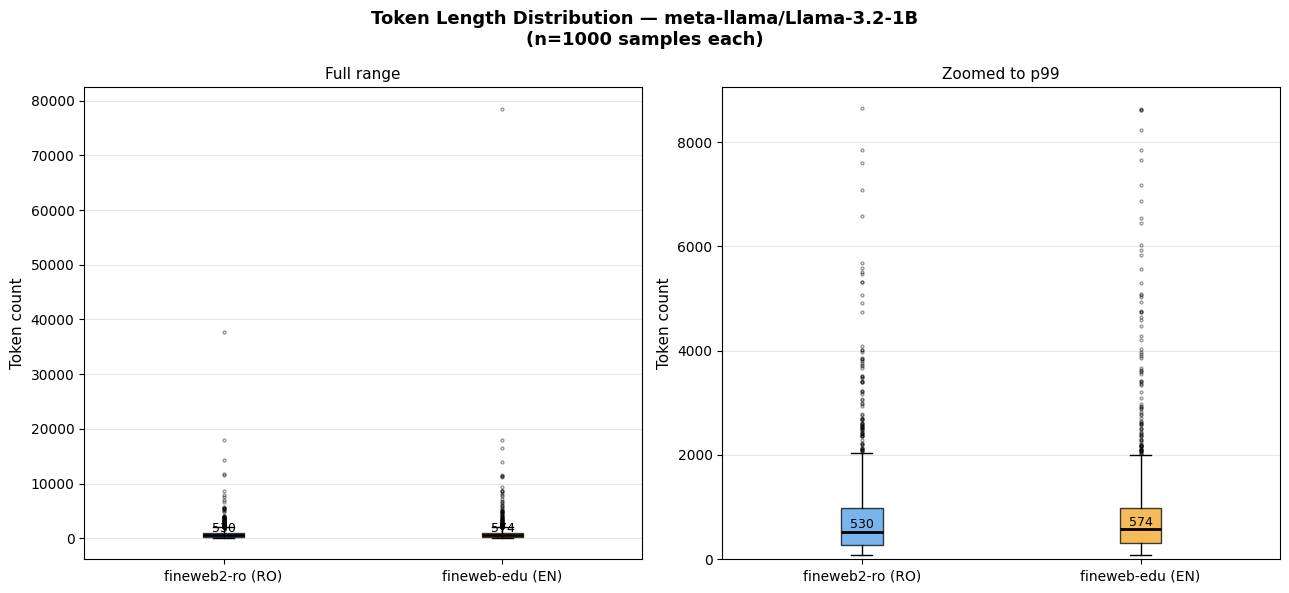

In [6]:
# ── Side-by-side boxplots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
fig.suptitle(
    f"Token Length Distribution — {MODEL_NAME}\n(n={N_SAMPLES} samples each)",
    fontsize=13, fontweight="bold"
)

colors = ["#4c9be8", "#f4a522"]
labels = list(results.keys())
data   = list(results.values())

# Left: full range
bp = axes[0].boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.4),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("Full range", fontsize=11)
axes[0].set_ylabel("Token count", fontsize=11)
axes[0].grid(True, axis="y", alpha=0.3)

# Right: zoomed to p99 to reduce outlier distortion
p99 = max(np.percentile(d, 99) for d in data)
bp2 = axes[1].boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.4),
)
for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylim(0, p99 * 1.05)
axes[1].set_title("Zoomed to p99", fontsize=11)
axes[1].set_ylabel("Token count", fontsize=11)
axes[1].grid(True, axis="y", alpha=0.3)

# Annotate medians
for ax in axes:
    for i, (label, d) in enumerate(results.items(), start=1):
        med = np.median(d)
        ax.text(i, med * 1.02, f"{med:.0f}", ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
out_path = Path("token_length_boxplot.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path.resolve()}")
plt.show()

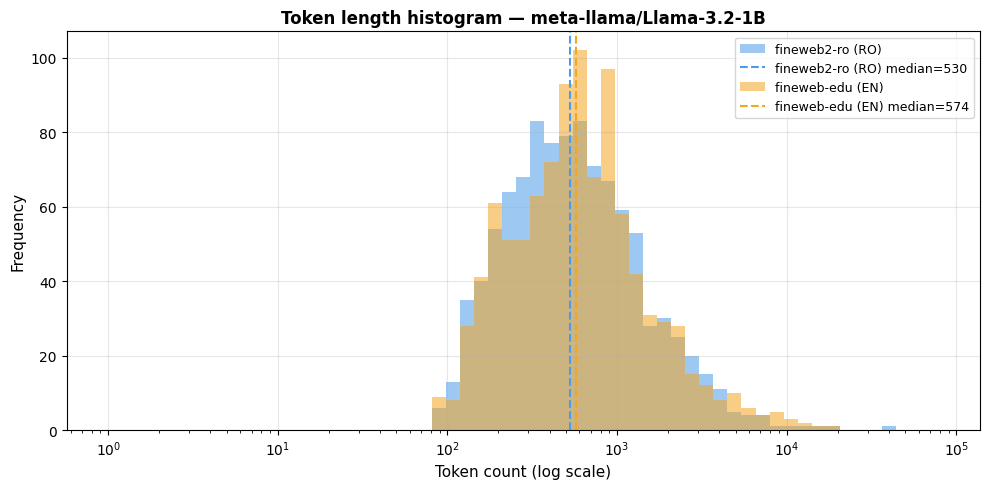

In [7]:
# ── Overlay histogram (log-x scale) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.logspace(np.log10(1), np.log10(max(d.max() for d in data)), 60)

for label, lengths, color in zip(labels, data, colors):
    ax.hist(lengths, bins=bins, alpha=0.55, color=color, label=label, edgecolor="none")
    ax.axvline(np.median(lengths), color=color, linestyle="--", linewidth=1.5,
               label=f"{label} median={np.median(lengths):.0f}")

ax.set_xscale("log")
ax.set_xlabel("Token count (log scale)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title(f"Token length histogram — {MODEL_NAME}", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()